In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [25]:
from data_science.plots import kmeans_metrics_plot, plot_clusters, plot_elbow, plot_pca_scatter


## Data


In [26]:
data = pd.read_csv(
    "./../../data/wine_quality_merged.csv",
)

## Prepare Data


In [27]:
RANDOM_STATE = 42
np.random.default_rng(RANDOM_STATE)

Generator(PCG64) at 0x1279F7D80

In [28]:
X = data.drop(columns=["type"])
y = data["type"]

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

## PCA


In [31]:
pca_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)
X_pca_2d = pca_2d.fit_transform(X_scaled)

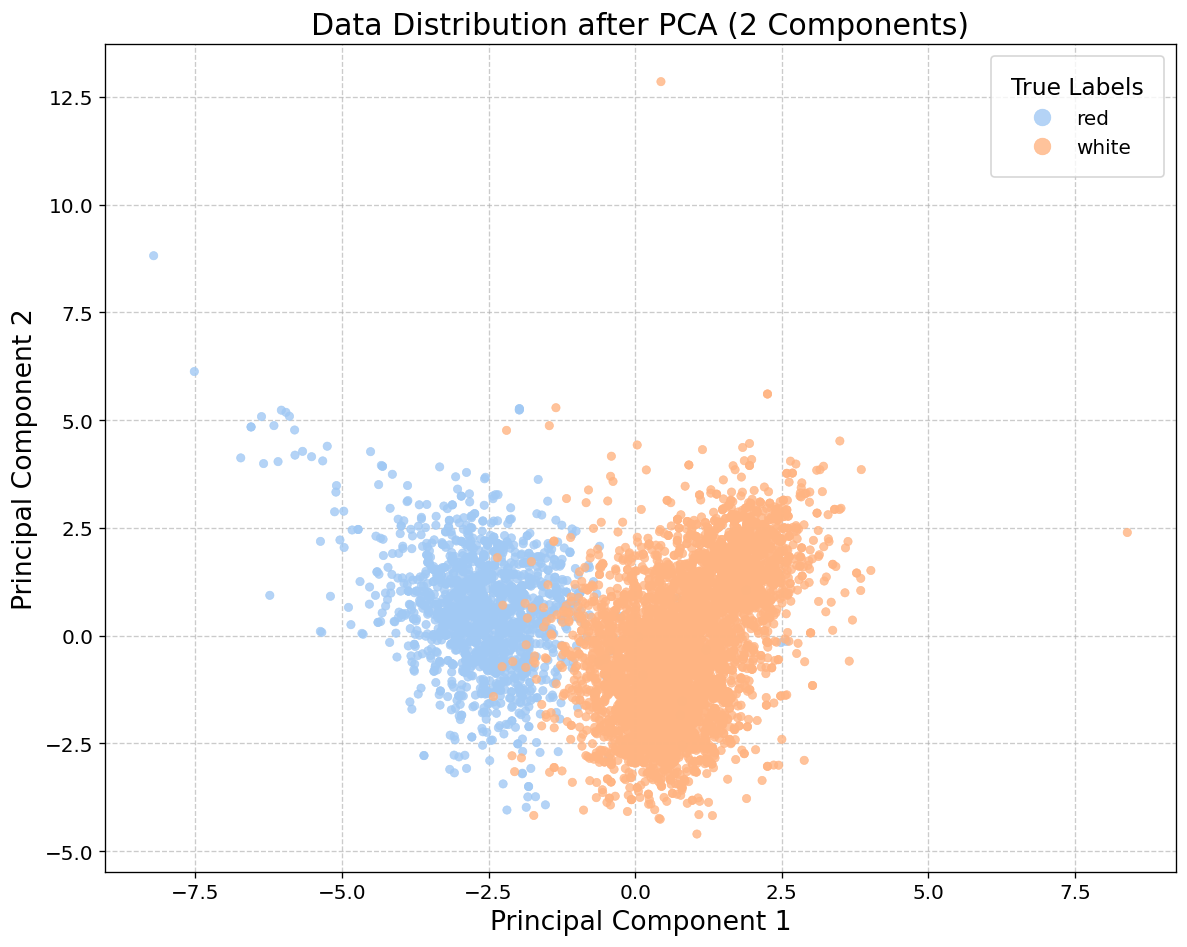

In [32]:
plot_pca_scatter(
    X_pca_2d,
    y,
    title='Data Distribution after PCA (2 Components)',
    palette='pastel',
)

## Kmeans


### Elbow Method


In [33]:
wcss = []
Ks = range(1, 16)
for k in Ks:
    kmeans = KMeans(
        n_init=10,
        n_clusters=k,
        init='k-means++',
        max_iter=500,
        random_state=RANDOM_STATE,
    )
    kmeans.fit(X_pca_2d)
    wcss.append(kmeans.inertia_)

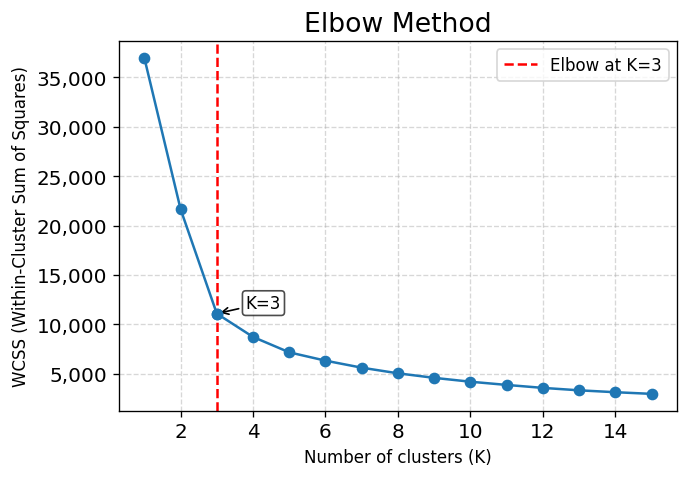

np.int64(3)

In [34]:
plot_elbow(Ks, wcss)

### KMeans (k=3)


In [35]:
kmeans_k3 = KMeans(
    n_clusters=3,
    n_init=10,
    init='k-means++',
    max_iter=500,
    random_state=RANDOM_STATE,
)
km_labels_k3 = kmeans_k3.fit_predict(X_pca_2d)

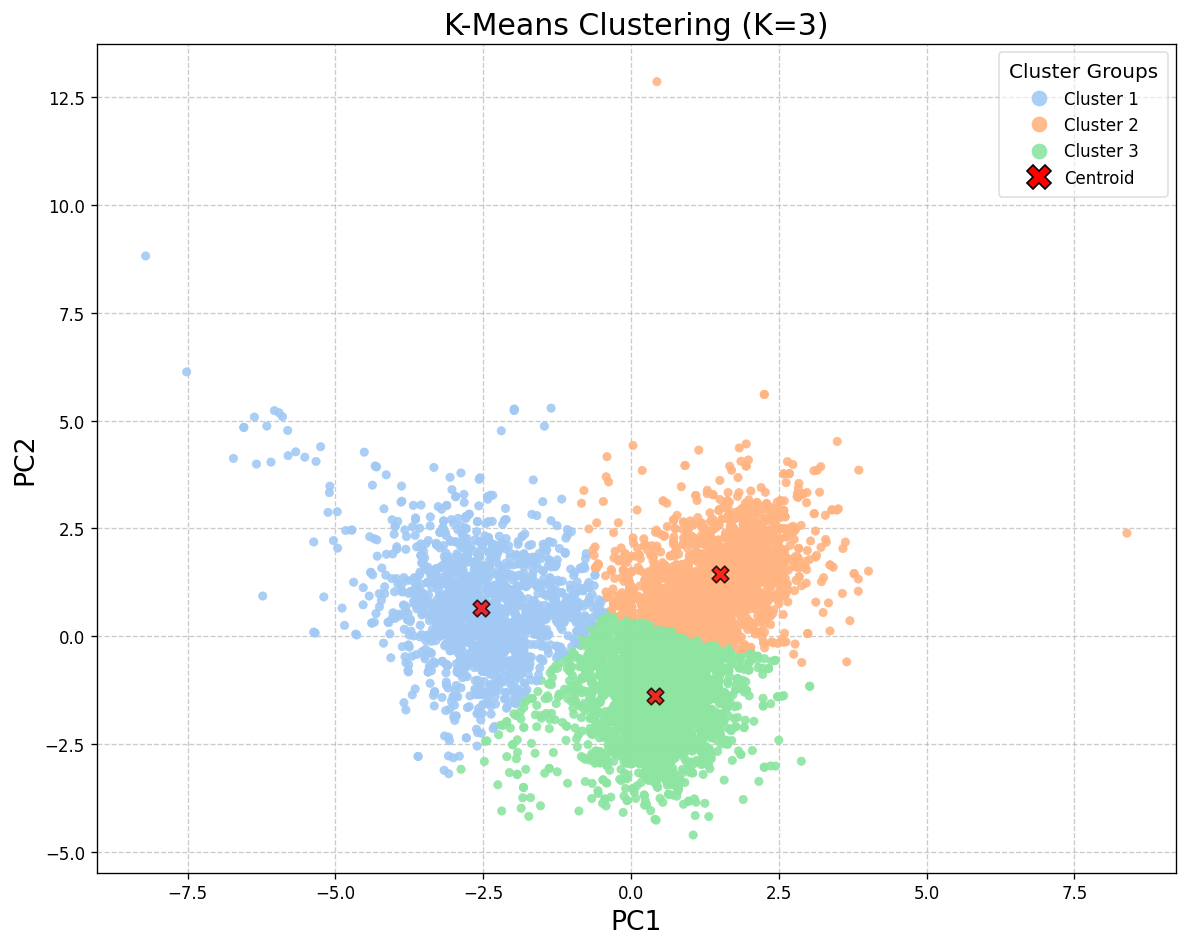

In [36]:
plot_clusters(
    km_labels_k3,
    X_pca_2d,
    title='K-Means Clustering (K=3)',
    palette='pastel',
)

### KMeans (k=2)


In [37]:
kmeans_k2 = KMeans(
    n_clusters=2,
    n_init=10,
    init='k-means++',
    max_iter=500,
    random_state=RANDOM_STATE,
)
km_labels_k2 = kmeans_k2.fit_predict(X_pca_2d)

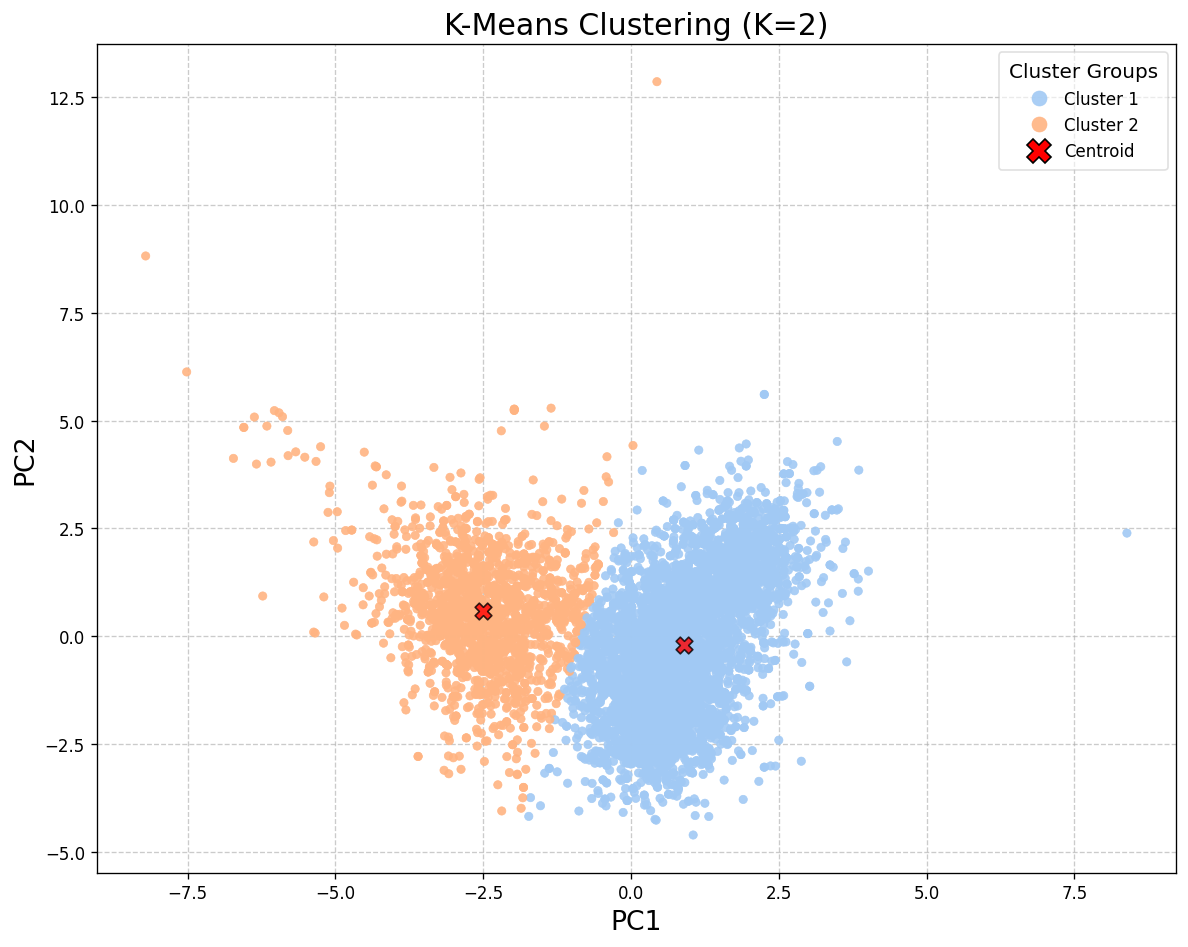

In [38]:
plot_clusters(
    km_labels_k2,
    X_pca_2d,
    title='K-Means Clustering (K=2)',
    palette='pastel',
)

### Evaluate KMeans Results


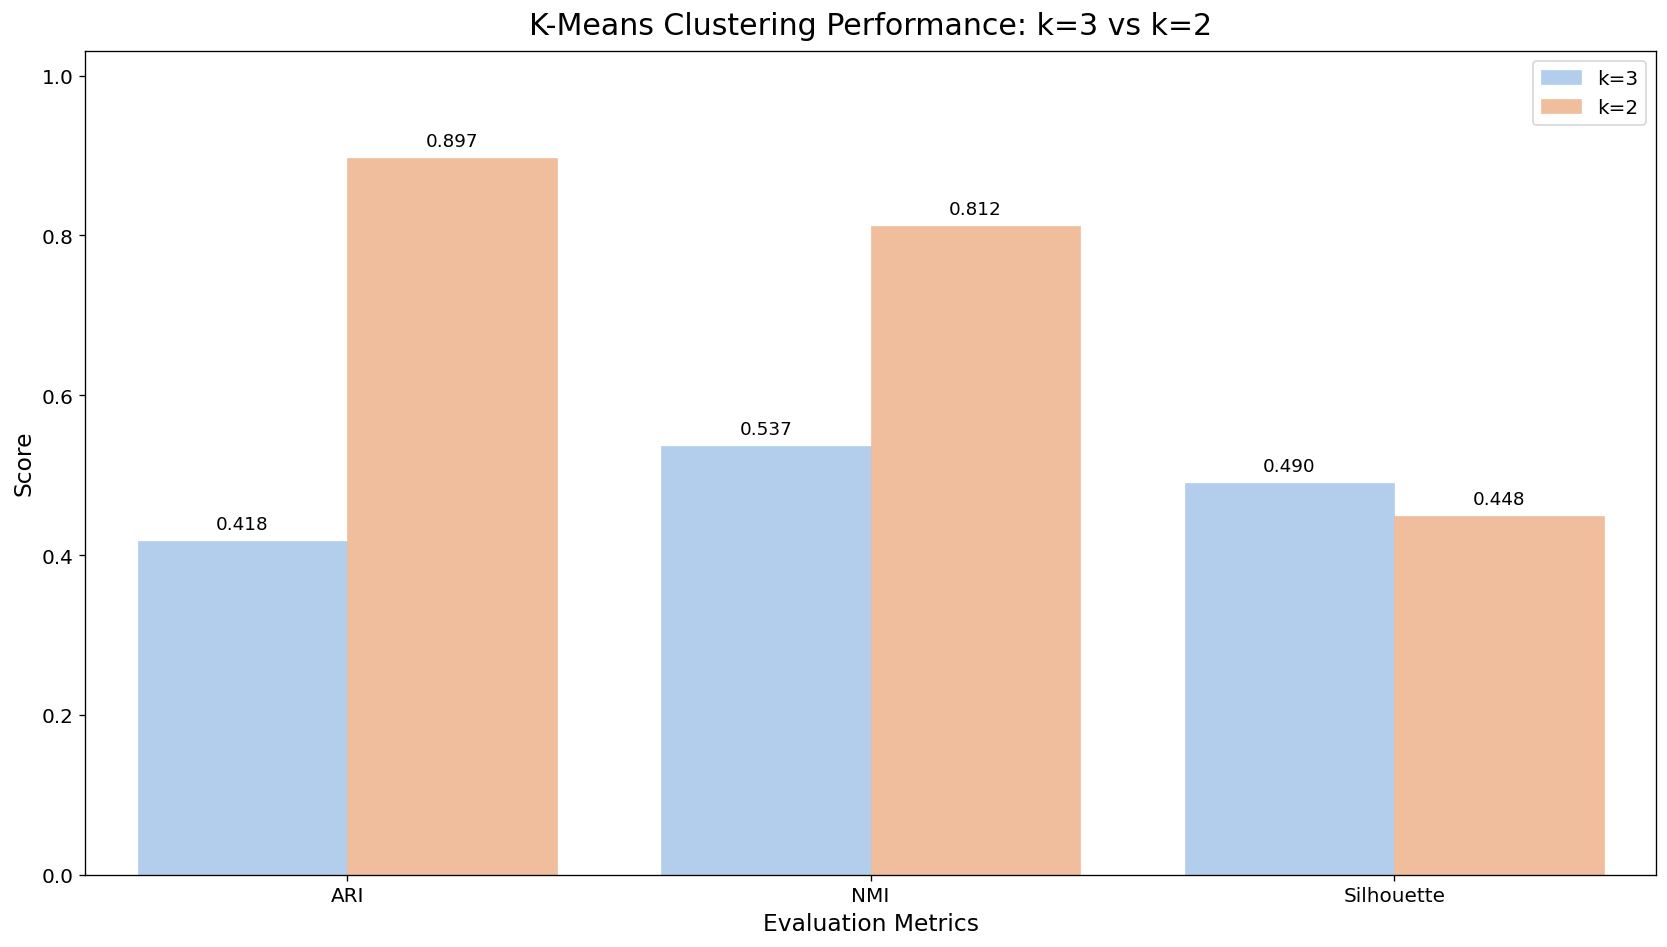

In [39]:
df_multi, fig_multi, ax_multi = kmeans_metrics_plot(
    runs=[
        {'label': 'k=3', 'true': y, 'labels': km_labels_k3, 'k': 3, 'inertia': kmeans_k3.inertia_},
        {'label': 'k=2', 'true': y, 'labels': km_labels_k2, 'k': 2, 'inertia': kmeans_k2.inertia_},
    ],
    X_data=X_pca_2d,
    metrics=[
        'adjusted_rand_score',
        'normalized_mutual_info',
        # "homogeneity_score",
        # "completeness_score",
        # "v_measure_score",
        'silhouette_score',
    ],
    palette='pastel',
)